In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import time
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.simplefilter('ignore')

In [2]:
file_path = "ner_dataset.csv"
model_name = 'bert-base-uncased'
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
torch.cuda.empty_cache()

In [4]:
class Preprocess(object):
    
    def __init__(self, file_path):
        self.data = pd.read_csv(file_path, encoding="unicode_escape")
        self.n_tags, self.n_pos, self.pos2ids, self.tags2ids, self.id2pos, self.id2tag = self.transform()
        self.pre_sentences, self.pos, self.tags = self.organise()
        self.sentences = self.clean()
        #self.correction()
    
    def correction(self):
        self.sentences[1901][0] = 'None'
        self.sentences[1956][0] = 'None'
        self.sentences = np.vectorize(lambda x: str(x))(self.sentences)

    def transform(self):
        tag_list = self.data['Tag'].unique()
        pos_list = self.data['POS'].unique()
        n_tags = len(tag_list)
        n_pos = len(pos_list)

        pos2ids = {pos: i+1 for i, pos in enumerate(pos_list)}
        id2pos = {i+1: pos for i, pos in enumerate(pos_list)}
        self.data["PosId"] = self.data["POS"].map(pos2ids)

        tags2ids = {tag: i+1 for i, tag in enumerate(tag_list)}
        id2tag = {i+1: tag for i, tag in enumerate(tag_list)}
        self.data["TagId"] = self.data["Tag"].map(tags2ids)

        return n_tags, n_pos, pos2ids, tags2ids, id2pos, id2tag

    def clean_text(self, text):
        text = text.lower()
        text = re.sub(r"i'm", "i am", text) # replace "i'm" with "i am"
        text = re.sub(r"im", "i am", text)
        text = re.sub(r"ive", "i have", text)
        text = re.sub(r"he's", "he is", text)
        text = re.sub(r"she's", "she is", text)
        text = re.sub(r"that's", "that is", text)
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"where's", "where is", text)
        text = re.sub(r"how's", "how is", text)
        text = re.sub(r"\'ll", " will", text)
        text = re.sub(r"\'ve", " have", text)
        text = re.sub(r"\'re", " are", text)
        text = re.sub(r"\'d", " would", text)
        text = re.sub(r"n't", "not", text)
        text = re.sub(r"won't", "will not", text)
        text = re.sub(r"wont", "will not", text)
        text = re.sub(r"won t", "will not", text)
        text = re.sub(r"didn't", "did not", text)
        text = re.sub(r"didnt", "did not", text)
        text = re.sub(r"didn t", "did not", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"cant", "cannot", text)
        text = re.sub(r"can t", "cannot", text)
        text = re.sub(r"[-()\"#/@:<>{}+=~|.?,!;]", "", text)
        return text 

    def clean(self):
        clean_sentences = [[self.clean_text(i) for i in x if type(i) == str] for x in self.pre_sentences]
        return clean_sentences

    def organise(self):

        self.data.rename(columns={'Sentence #':'Sentence'}, inplace=True)
        self.data["Sentence"] = self.data["Sentence"].fillna(method='ffill')

        sentences = self.data.groupby('Sentence')['Word'].apply(list).values
        pos = self.data.groupby('Sentence')['PosId'].apply(list).values
        tags = self.data.groupby('Sentence')['TagId'].apply(list).values

        return sentences, pos, tags
    
pre = Preprocess(file_path)

In [5]:
pre.sentences[0]

['thousands',
 'of',
 'demonstrators',
 'have',
 'marched',
 'through',
 'london',
 'to',
 'protest',
 'the',
 'war',
 'in',
 'iraq',
 'and',
 'demand',
 'the',
 'withdrawal',
 'of',
 'british',
 'troops',
 'from',
 'that',
 'country',
 '']

In [6]:
class NerDataset(Dataset):
    
    def __init__(self, sentences, pos_id, tag_id, tokenizer, max_len=128):
        super(NerDataset, self).__init__()
        self.text = sentences
        self.pos_id = pos_id
        self.tag_id = tag_id
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.text)
    
    def __getitem__(self, x):
        text = self.text[x]
        pos = self.pos_id[x]
        tag = self.tag_id[x]
        ids = []
        attention_mask = []
        token_type_ids = []

        for i in text:
            encoding = self.tokenizer(i, add_special_tokens=False)
            ids.extend(encoding['input_ids'])
            attention_mask.extend(encoding['attention_mask'])
            token_type_ids.extend(encoding['token_type_ids'])

        # [101]: CLS, [102]: SEP, [0]: PAD
        ids = [101] + ids + [102]
        pos = [0] + pos + [0]
        tag = [0] + tag + [0]
        pos = pos + [0]*(self.max_len - len(pos))
        tag = tag + [0]*(self.max_len - len(tag))
        pos = pos[:128]
        tag = tag[:128]

        ids = ids + [0]*(self.max_len - len(ids))
        attention_mask = attention_mask + [0]*(self.max_len - len(attention_mask))
        token_type_ids = token_type_ids + [0]*(self.max_len - len(token_type_ids))
        
        return {'input_ids': torch.tensor(ids, dtype=torch.long, device=device), 
                'pos': torch.tensor(pos, dtype=torch.long, device=device), 
                'tag': torch.tensor(tag, dtype=torch.long, device=device),
                'attention_mask': torch.tensor(attention_mask, dtype=torch.long, device=device), 
                'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long, device=device)}

In [7]:
train_sentence, valid_sentence, train_pos, valid_pos, train_tags, valid_tags = train_test_split(pre.sentences, pre.pos, pre.tags, test_size=0.1)

In [8]:
tokenizer = BertTokenizer.from_pretrained(model_name)

In [9]:
train_dataset = NerDataset(train_sentence, train_pos, train_tags, tokenizer)
train_dataloader = DataLoader(train_dataset, batch_size=16, drop_last=True)

valid_dataset = NerDataset(valid_sentence, valid_pos, valid_tags, tokenizer)
valid_dataloader = DataLoader(valid_dataset, batch_size=16, drop_last=True)

In [10]:
for i in train_dataloader:
    print(i['input_ids'].size())
    print(i['pos'].size())
    print(i['tag'].size())
    print(i['attention_mask'].size())
    print(i['token_type_ids'].size())
    break

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16, 128])


In [11]:
class NerModel(nn.Module):
    
    def __init__(self, bert_model_name, n_pos, n_tags, hidden_size=256):
        super(NerModel, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)

        self.pos_dropout = nn.Dropout(0.3)
        self.tag_dropout = nn.Dropout(0.3)

        self.fc_pos_linear = nn.Linear(self.bert.config.hidden_size, hidden_size)
        self.fc_tag_linear = nn.Linear(self.bert.config.hidden_size, hidden_size)

        self.fc_pos = nn.Linear(hidden_size, n_pos + 1)
        self.fc_tag = nn.Linear(hidden_size, n_tags + 1)

        
    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(input_ids, attention_mask, token_type_ids)
        pooler_outputs = outputs.last_hidden_state

        x_pos = self.fc_pos_linear(pooler_outputs)
        x_tag = self.fc_tag_linear(pooler_outputs)

        x_pos = self.pos_dropout(x_pos)
        x_tag = self.tag_dropout(x_tag)

        x_pos = self.fc_pos(x_pos)
        x_tag = self.fc_tag(x_tag)

        return x_pos, x_tag

In [12]:
learning_rate = 1e-5
num_epochs = 20
model = NerModel(model_name, pre.n_pos, pre.n_tags).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
total_steps = len(train_dataloader) * num_epochs

#scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# ✅ Fix — warmup over first 10% of steps
warmup_steps = int(total_steps * 0.1)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

criterion = nn.CrossEntropyLoss().to(device)

In [13]:
def loss_fn(prediction, target, masks, criterion, n_classes):
    logits = prediction.view(-1, n_classes)
    masks = masks.view(-1)
    target = target.view(-1)
    target = torch.where(masks == 1, target, torch.tensor(criterion.ignore_index).type_as(target))
    return criterion(logits, target)

In [14]:
def train(model, data_loader, optimizer, scheduler, criterion):
    
    model.train()
    for batch in data_loader:
        optimizer.zero_grad()
        pos_output, tag_output = model(input_ids = batch['input_ids'], attention_mask = batch['attention_mask'], token_type_ids = batch['token_type_ids'])
        pos_loss = loss_fn(pos_output, batch['pos'], batch['attention_mask'], criterion, pre.n_pos + 1)
        tag_loss = loss_fn(tag_output, batch['tag'], batch['attention_mask'], criterion, pre.n_tags + 1)
        loss = (pos_loss + tag_loss)/2
        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ✅ add this

        optimizer.step()
        scheduler.step()

In [18]:
def evaluate(model, data_loader):

    model.eval()
    pos_loss_list = []
    tag_loss_list = []
    all_pos_preds, all_pos_labels = [], []
    all_tag_preds, all_tag_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            pos_output, tag_output = model(input_ids = batch['input_ids'], attention_mask = batch['attention_mask'], token_type_ids = batch['token_type_ids'])
            pos_loss = loss_fn(pos_output, batch['pos'], batch['attention_mask'], criterion, pre.n_pos + 1)
            tag_loss = loss_fn(tag_output, batch['tag'], batch['attention_mask'], criterion, pre.n_tags + 1)
            pos_loss_list.append(pos_loss)
            tag_loss_list.append(tag_loss)

            mask = batch['attention_mask'].view(-1).bool().cpu()
            pos_preds  = torch.argmax(pos_output, dim=-1).view(-1).cpu()[mask]
            tag_preds  = torch.argmax(tag_output, dim=-1).view(-1).cpu()[mask]
            pos_labels = batch['pos'].view(-1).cpu()[mask]
            tag_labels = batch['tag'].view(-1).cpu()[mask]

            valid_pos = pos_labels != 0
            all_pos_preds.extend(pos_preds[valid_pos].numpy())
            all_pos_labels.extend(pos_labels[valid_pos].numpy())

            valid_tag = tag_labels != 0
            all_tag_preds.extend(tag_preds[valid_tag].numpy())
            all_tag_labels.extend(tag_labels[valid_tag].numpy())

    avg_pos_loss = sum(pos_loss_list) / len(pos_loss_list)
    avg_tag_loss = sum(tag_loss_list) / len(tag_loss_list)

    pos_names = {v: k for k, v in pre.pos2ids.items()}
    tag_names = {v: k for k, v in pre.tags2ids.items()}

    pos_label_ids = sorted(set(all_pos_labels))
    tag_label_ids = sorted(set(all_tag_labels))

    print("\n--- POS Classification Report ---")
    print(classification_report(
        all_pos_labels, all_pos_preds,
        labels=pos_label_ids,
        target_names=[pos_names.get(i, str(i)) for i in pos_label_ids],
        zero_division=0))

    print("--- TAG (NER) Classification Report ---")
    print(classification_report(
        all_tag_labels, all_tag_preds,
        labels=tag_label_ids,
        target_names=[tag_names.get(i, str(i)) for i in tag_label_ids],
        zero_division=0))

    return avg_pos_loss, avg_tag_loss

In [19]:
for epoch in range(num_epochs):
    tic = time.time()
    print("-----------------------------------")
    print(f"Epoch {epoch + 1}")
    train(model, train_dataloader, optimizer, scheduler, criterion)
    pos_loss, tag_loss = evaluate(model, valid_dataloader)
    print("POS: ", pos_loss)
    print("TAG: ", tag_loss)
    print("-----------------")
    toc = time.time()
    print("epoch time: ", toc-tic)

    torch.save(model.state_dict(), f'weights/model_epoch_{epoch}.pt')

-----------------------------------
Epoch 1

--- POS Classification Report ---
              precision    recall  f1-score   support

         NNS       0.65      0.66      0.65      7038
          IN       0.60      0.66      0.63     11786
         VBP       0.76      0.72      0.74      1555
         VBN       0.70      0.62      0.66      3150
         NNP       0.72      0.79      0.76     12934
          TO       0.58      0.62      0.60      2385
          VB       0.52      0.59      0.55      2488
          DT       0.67      0.74      0.71      9473
          NN       0.63      0.62      0.62     13617
          CC       0.50      0.51      0.50      2257
          JJ       0.64      0.61      0.63      7558
           .       0.41      0.42      0.42      2309
         VBD       0.67      0.68      0.68      3826
          WP       0.00      0.00      0.00       275
          ``       0.00      0.00      0.00       323
          CD       0.56      0.67      0.61      2228
  

In [20]:
class NerPredictor(object):

    def __init__(self, model, tokenizer, pre, max_len=128):
        self.model = model
        self.tokenizer = tokenizer
        self.pre = pre
        self.max_len = max_len

    def encode(self, sentence):
        words = sentence.strip().split()
        words = [self.pre.clean_text(w) for w in words if w]

        ids = [101]
        attention_mask = []
        token_type_ids = []
        word_positions = []  # index of first token for each word

        for word in words:
            encoding = self.tokenizer(word, add_special_tokens=False)
            word_positions.append(len(ids))  # position in ids (after CLS)
            ids.extend(encoding['input_ids'])
            attention_mask.extend(encoding['attention_mask'])
            token_type_ids.extend(encoding['token_type_ids'])

        ids = ids + [102]
        ids = ids + [0] * (self.max_len - len(ids))
        attention_mask = [1] + attention_mask + [1] + [0] * (self.max_len - len(attention_mask) - 2)
        token_type_ids = [0] + token_type_ids + [0] + [0] * (self.max_len - len(token_type_ids) - 2)

        input_ids = torch.tensor([ids], dtype=torch.long, device=device)
        attn_mask = torch.tensor([attention_mask], dtype=torch.long, device=device)
        tok_type  = torch.tensor([token_type_ids], dtype=torch.long, device=device)

        return words, word_positions, input_ids, attn_mask, tok_type

    def predict(self, sentence):
        words, word_positions, input_ids, attn_mask, tok_type = self.encode(sentence)

        self.model.eval()
        with torch.no_grad():
            pos_output, tag_output = self.model(input_ids=input_ids, attention_mask=attn_mask, token_type_ids=tok_type)

        pos_preds = torch.argmax(pos_output, dim=-1).squeeze(0).cpu().numpy()
        tag_preds = torch.argmax(tag_output, dim=-1).squeeze(0).cpu().numpy()

        results = []
        for word, pos_idx in zip(words, word_positions):
            pos_label = self.pre.id2pos.get(pos_preds[pos_idx], 'O')
            tag_label = self.pre.id2tag.get(tag_preds[pos_idx], 'O')
            results.append({'word': word, 'pos': pos_label, 'tag': tag_label})

        return results

    def visualize(self, sentence):
        results = self.predict(sentence)

        tag_set = list(set(r['tag'] for r in results))
        cmap = plt.cm.get_cmap('tab20', len(tag_set))
        tag_colors = {tag: cmap(i) for i, tag in enumerate(tag_set)}

        fig, ax = plt.subplots(figsize=(max(10, len(results) * 1.2), 2.5))
        ax.set_xlim(0, len(results))
        ax.set_ylim(0, 1)
        ax.axis('off')

        for i, token in enumerate(results):
            color = tag_colors[token['tag']]
            rect = mpatches.FancyBboxPatch((i + 0.05, 0.35), 0.85, 0.4,
                                           boxstyle="round,pad=0.05",
                                           linewidth=1, edgecolor='gray',
                                           facecolor=color, alpha=0.8)
            ax.add_patch(rect)
            ax.text(i + 0.475, 0.57, token['word'], ha='center', va='center',
                    fontsize=10, fontweight='bold', color='black')
            ax.text(i + 0.475, 0.25, token['tag'], ha='center', va='center',
                    fontsize=8, color='dimgray')
            ax.text(i + 0.475, 0.12, token['pos'], ha='center', va='center',
                    fontsize=7, color='steelblue')

        legend_patches = [mpatches.Patch(color=tag_colors[t], label=t) for t in tag_set]
        ax.legend(handles=legend_patches, loc='upper right', fontsize=8,
                  bbox_to_anchor=(1, 1.3), ncol=min(5, len(tag_set)))

        ax.set_title("NER Predictions  (gray = TAG  |  blue = POS)", fontsize=11, pad=20)
        plt.tight_layout()
        plt.show()

        return results

In [24]:
def test(model, data_loader):
    model.eval()
    pos_loss_list = []
    tag_loss_list = []
    all_pos_preds, all_pos_labels = [], []
    all_tag_preds, all_tag_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            pos_output, tag_output = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                token_type_ids=batch['token_type_ids'])

            pos_loss = loss_fn(pos_output, batch['pos'], batch['attention_mask'], criterion, pre.n_pos + 1)
            tag_loss = loss_fn(tag_output, batch['tag'], batch['attention_mask'], criterion, pre.n_tags + 1)
            pos_loss_list.append(pos_loss)
            tag_loss_list.append(tag_loss)

            mask = batch['attention_mask'].view(-1).bool().cpu()
            pos_preds = torch.argmax(pos_output, dim=-1).view(-1).cpu()[mask]
            tag_preds = torch.argmax(tag_output, dim=-1).view(-1).cpu()[mask]
            pos_labels = batch['pos'].view(-1).cpu()[mask]
            tag_labels = batch['tag'].view(-1).cpu()[mask]

            valid_pos = pos_labels != 0
            all_pos_preds.extend(pos_preds[valid_pos].numpy())
            all_pos_labels.extend(pos_labels[valid_pos].numpy())

            valid_tag = tag_labels != 0
            all_tag_preds.extend(tag_preds[valid_tag].numpy())
            all_tag_labels.extend(tag_labels[valid_tag].numpy())

    avg_pos_loss = sum(pos_loss_list) / len(pos_loss_list)
    avg_tag_loss = sum(tag_loss_list) / len(tag_loss_list)

    pos_names = {v: k for k, v in pre.pos2ids.items()}
    tag_names = {v: k for k, v in pre.tags2ids.items()}

    pos_label_ids = sorted(set(all_pos_labels))
    tag_label_ids = sorted(set(all_tag_labels))

    print("=" * 50)
    print(f"TEST LOSS  —  POS: {avg_pos_loss:.4f}  |  TAG: {avg_tag_loss:.4f}")
    print("=" * 50)
    print("\n--- POS Classification Report ---")
    print(classification_report(
        all_pos_labels, all_pos_preds,
        labels=pos_label_ids,
        target_names=[pos_names.get(i, str(i)) for i in pos_label_ids],
        zero_division=0))
    print("\n--- TAG (NER) Classification Report ---")
    print(classification_report(
        all_tag_labels, all_tag_preds,
        labels=tag_label_ids,
        target_names=[tag_names.get(i, str(i)) for i in tag_label_ids],
        zero_division=0))

    return avg_pos_loss, avg_tag_loss

In [25]:
# Cell: Load best model and run test
model.load_state_dict(torch.load('weights/model_epoch_7.pt'))
test_pos_loss, test_tag_loss = test(model, valid_dataloader)

TEST LOSS  —  POS: 0.7150  |  TAG: 0.2498

--- POS Classification Report ---
              precision    recall  f1-score   support

         NNS       0.79      0.80      0.80      7038
          IN       0.79      0.80      0.80     11786
         VBP       0.84      0.85      0.85      1555
         VBN       0.79      0.80      0.80      3150
         NNP       0.85      0.85      0.85     12934
          TO       0.75      0.80      0.78      2385
          VB       0.76      0.77      0.77      2488
          DT       0.82      0.85      0.83      9473
          NN       0.79      0.77      0.78     13617
          CC       0.68      0.72      0.70      2257
          JJ       0.78      0.79      0.79      7558
           .       0.71      0.67      0.69      2309
         VBD       0.81      0.81      0.81      3826
          WP       0.64      0.74      0.69       275
          ``       0.43      0.02      0.04       323
          CD       0.78      0.80      0.79      2228
    

In [26]:
class NerPredictor(object):

    def __init__(self, model, tokenizer, pre, max_len=128):
        self.model = model
        self.tokenizer = tokenizer
        self.pre = pre
        self.max_len = max_len

    def encode(self, sentence):
        words = sentence.strip().split()
        words = [self.pre.clean_text(w) for w in words if w]

        ids = [101]
        attention_mask = []
        token_type_ids = []
        word_positions = []  # index of first token for each word

        for word in words:
            encoding = self.tokenizer(word, add_special_tokens=False)
            word_positions.append(len(ids))  # position in ids (after CLS)
            ids.extend(encoding['input_ids'])
            attention_mask.extend(encoding['attention_mask'])
            token_type_ids.extend(encoding['token_type_ids'])

        ids = ids + [102]
        ids = ids + [0] * (self.max_len - len(ids))
        attention_mask = [1] + attention_mask + [1] + [0] * (self.max_len - len(attention_mask) - 2)
        token_type_ids = [0] + token_type_ids + [0] + [0] * (self.max_len - len(token_type_ids) - 2)

        input_ids = torch.tensor([ids], dtype=torch.long, device=device)
        attn_mask = torch.tensor([attention_mask], dtype=torch.long, device=device)
        tok_type  = torch.tensor([token_type_ids], dtype=torch.long, device=device)

        return words, word_positions, input_ids, attn_mask, tok_type

    def predict(self, sentence):
        words, word_positions, input_ids, attn_mask, tok_type = self.encode(sentence)

        self.model.eval()
        with torch.no_grad():
            pos_output, tag_output = self.model(input_ids=input_ids, attention_mask=attn_mask, token_type_ids=tok_type)

        pos_preds = torch.argmax(pos_output, dim=-1).squeeze(0).cpu().numpy()
        tag_preds = torch.argmax(tag_output, dim=-1).squeeze(0).cpu().numpy()

        results = []
        for word, pos_idx in zip(words, word_positions):
            pos_label = self.pre.id2pos.get(pos_preds[pos_idx], 'O')
            tag_label = self.pre.id2tag.get(tag_preds[pos_idx], 'O')
            results.append({'word': word, 'pos': pos_label, 'tag': tag_label})

        return results

    def visualize(self, sentence):
        results = self.predict(sentence)

        tag_set = list(set(r['tag'] for r in results))
        cmap = plt.cm.get_cmap('tab20', len(tag_set))
        tag_colors = {tag: cmap(i) for i, tag in enumerate(tag_set)}

        fig, ax = plt.subplots(figsize=(max(10, len(results) * 1.2), 2.5))
        ax.set_xlim(0, len(results))
        ax.set_ylim(0, 1)
        ax.axis('off')

        for i, token in enumerate(results):
            color = tag_colors[token['tag']]
            rect = mpatches.FancyBboxPatch((i + 0.05, 0.35), 0.85, 0.4,
                                           boxstyle="round,pad=0.05",
                                           linewidth=1, edgecolor='gray',
                                           facecolor=color, alpha=0.8)
            ax.add_patch(rect)
            ax.text(i + 0.475, 0.57, token['word'], ha='center', va='center',
                    fontsize=10, fontweight='bold', color='black')
            ax.text(i + 0.475, 0.25, token['tag'], ha='center', va='center',
                    fontsize=8, color='dimgray')
            ax.text(i + 0.475, 0.12, token['pos'], ha='center', va='center',
                    fontsize=7, color='steelblue')

        legend_patches = [mpatches.Patch(color=tag_colors[t], label=t) for t in tag_set]
        ax.legend(handles=legend_patches, loc='upper right', fontsize=8,
                  bbox_to_anchor=(1, 1.3), ncol=min(5, len(tag_set)))

        ax.set_title("NER Predictions  (gray = TAG  |  blue = POS)", fontsize=11, pad=20)
        plt.tight_layout()
        plt.show()

        return results

barack           TAG: B-per       POS: NNP
obama            TAG: I-per       POS: NNP
visited          TAG: O           POS: VBD
london           TAG: B-geo       POS: NNP
last             TAG: O           POS: JJ
tuesday          TAG: B-tim       POS: NNP


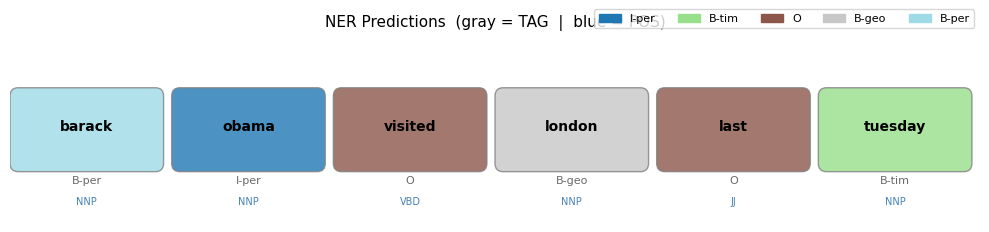

[{'word': 'barack', 'pos': 'NNP', 'tag': 'B-per'},
 {'word': 'obama', 'pos': 'NNP', 'tag': 'I-per'},
 {'word': 'visited', 'pos': 'VBD', 'tag': 'O'},
 {'word': 'london', 'pos': 'NNP', 'tag': 'B-geo'},
 {'word': 'last', 'pos': 'JJ', 'tag': 'O'},
 {'word': 'tuesday', 'pos': 'NNP', 'tag': 'B-tim'}]

In [27]:
predictor = NerPredictor(model, tokenizer, pre)

# Print results
results = predictor.predict("Barack Obama visited London last Tuesday")
for r in results:
    print(f"{r['word']:15s}  TAG: {r['tag']:10s}  POS: {r['pos']}")

# Visualize
predictor.visualize("Barack Obama visited London last Tuesday")